# Task 2: Quantitative Analysis — Technical Indicators

This notebook loads historical stock price data for the top tickers from the analyst ratings dataset, computes financial technical indicators with **TA-Lib**, applies **PyNance** for additional financial metrics, and produces visualisations of price action alongside the indicators.

**Tickers analysed:** AAPL, MSFT, NVDA, TSLA, GOOG

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os

# Resolve project root so paths work regardless of where Jupyter was launched
_cwd = Path().resolve()
ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
os.chdir(ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import talib
import pynance as pn

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKERS = ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'GOOG']
START = '2020-01-01'
END   = '2024-12-31'

print('Libraries loaded successfully.')
print(f'Working directory: {Path.cwd()}')

Libraries loaded successfully.
Working directory: /home/kalkidan_fantu/tenx/kaim/news-sentiment-analysis


## 2. Load Historical Stock Price Data

The tickers are chosen from the top-mentioned stocks in the analyst ratings dataset (`raw_analyst_ratings.csv`). We download adjusted OHLCV data from Yahoo Finance.

In [2]:
raw_ratings = pd.read_csv('data/raw/raw_analyst_ratings.csv', index_col=0)
print('Top 10 most-mentioned tickers in analyst ratings dataset:')
print(raw_ratings['stock'].value_counts().head(10))

Top 10 most-mentioned tickers in analyst ratings dataset:
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64


In [3]:
def download_stock(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Download adjusted OHLCV data and return a flat DataFrame."""
    raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    # Flatten MultiIndex columns produced by yfinance
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [col[0] for col in raw.columns]
    return raw

stocks = {ticker: download_stock(ticker, START, END) for ticker in TICKERS}

for ticker, df in stocks.items():
    print(f"{ticker}: {df.shape[0]} rows, {df.shape[1]} columns  |  "
          f"{df.index[0].date()} → {df.index[-1].date()}")

AAPL: 1257 rows, 5 columns  |  2020-01-02 → 2024-12-30
MSFT: 1257 rows, 5 columns  |  2020-01-02 → 2024-12-30
NVDA: 1257 rows, 5 columns  |  2020-01-02 → 2024-12-30
TSLA: 1257 rows, 5 columns  |  2020-01-02 → 2024-12-30
GOOG: 1257 rows, 5 columns  |  2020-01-02 → 2024-12-30


## 3. Data Preparation — Column Types & Missing Values

In [4]:
def inspect_and_clean(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']

    # Ensure correct dtypes
    for col in ohlcv:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    missing_before = df[ohlcv].isna().sum()
    
    # Forward-fill then backward-fill for any gaps (e.g. market holidays)
    df[ohlcv] = df[ohlcv].ffill().bfill()

    missing_after = df[ohlcv].isna().sum()

    print(f"\n{ticker}")
    print(f"  Missing values before fill: {missing_before.sum()}")
    print(f"  Missing values after  fill: {missing_after.sum()}")
    print(f"  Dtypes: { {c: str(df[c].dtype) for c in ohlcv} }")
    return df

stocks = {t: inspect_and_clean(df, t) for t, df in stocks.items()}


AAPL
  Missing values before fill: 0
  Missing values after  fill: 0
  Dtypes: {'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'int64'}

MSFT
  Missing values before fill: 0
  Missing values after  fill: 0
  Dtypes: {'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'int64'}

NVDA
  Missing values before fill: 0
  Missing values after  fill: 0
  Dtypes: {'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'int64'}

TSLA
  Missing values before fill: 0
  Missing values after  fill: 0
  Dtypes: {'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'int64'}

GOOG
  Missing values before fill: 0
  Missing values after  fill: 0
  Dtypes: {'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'int64'}


In [5]:
# Quick statistical summary for AAPL
print('AAPL descriptive statistics:')
stocks['AAPL'][['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2)

AAPL descriptive statistics:


,Open,High,Low,Close,Volume
count,1257.00,1257.00,1257.00,1257.00,1.257000e+03
mean,151.28,152.96,149.74,151.44,9.061168e+07
std,41.76,41.96,41.59,41.82,5.324605e+07
min,55.11,55.21,51.37,54.21,2.323470e+07
25%,125.84,127.45,124.35,126.37,5.546960e+07
50%,149.91,151.83,148.08,150.08,7.629970e+07
75%,175.76,177.61,174.48,175.91,1.077601e+08
max,256.79,258.69,256.23,257.61,4.265100e+08


## 4. Technical Indicators with TA-Lib

### 4.1 Simple Moving Average (SMA) & Exponential Moving Average (EMA)

Moving averages smooth price series to reveal trend direction.  
- **SMA-20** reacts slowly; **SMA-50** and **SMA-200** are widely-watched trend filters.  
- **EMA** weights recent prices more heavily, making it more responsive to price changes.

In [6]:
def add_moving_averages(df: pd.DataFrame) -> pd.DataFrame:
    close = df['Close'].values.astype(float)
    df['SMA_20']  = talib.SMA(close, timeperiod=20)
    df['SMA_50']  = talib.SMA(close, timeperiod=50)
    df['SMA_200'] = talib.SMA(close, timeperiod=200)
    df['EMA_12']  = talib.EMA(close, timeperiod=12)
    df['EMA_26']  = talib.EMA(close, timeperiod=26)
    return df

for ticker in TICKERS:
    stocks[ticker] = add_moving_averages(stocks[ticker])

print('Moving averages added.')
stocks['AAPL'][['Close', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26']].tail(5)

Moving averages added.


,Close,SMA_20,SMA_50,SMA_200,EMA_12,EMA_26
Date,,,,,,
2024-12-23,253.883102,243.695760,234.001646,209.838113,247.699222,241.958772
2024-12-24,256.797241,244.955381,234.541780,210.266139,249.098917,243.057918
2024-12-26,257.612732,246.146872,235.047557,210.695865,250.408735,244.136052
2024-12-27,254.201370,247.174260,235.526237,211.118938,250.992217,244.881631
2024-12-30,250.829788,247.913721,235.930133,211.515888,250.967228,245.322235


### 4.2 Relative Strength Index (RSI)

RSI (14-period) oscillates between 0 and 100.  
- **RSI > 70** → overbought (potential sell signal)  
- **RSI < 30** → oversold  (potential buy signal)

In [7]:
def add_rsi(df: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    df[f'RSI_{period}'] = talib.RSI(df['Close'].values.astype(float), timeperiod=period)
    return df

for ticker in TICKERS:
    stocks[ticker] = add_rsi(stocks[ticker])

print('RSI added.')
# Show overbought/oversold signal counts for each ticker
for ticker in TICKERS:
    rsi = stocks[ticker]['RSI_14'].dropna()
    ob = (rsi > 70).sum()
    os_ = (rsi < 30).sum()
    print(f"{ticker}: overbought days={ob:>4}  oversold days={os_:>4}  last RSI={rsi.iloc[-1]:.1f}")

RSI added.
AAPL: overbought days= 139  oversold days=  17  last RSI=60.2
MSFT: overbought days= 103  oversold days=  12  last RSI=40.6
NVDA: overbought days= 180  oversold days=  10  last RSI=49.9
TSLA: overbought days= 145  oversold days=  57  last RSI=54.6
GOOG: overbought days=  83  oversold days=  19  last RSI=58.2


### 4.3 MACD (Moving Average Convergence Divergence)

MACD = EMA(12) − EMA(26).  
- **Signal line** = EMA(9) of MACD  
- **Histogram** = MACD − Signal  
- Crossovers of MACD above the Signal line suggest bullish momentum.

In [8]:
def add_macd(df: pd.DataFrame) -> pd.DataFrame:
    macd, signal, hist = talib.MACD(
        df['Close'].values.astype(float),
        fastperiod=12, slowperiod=26, signalperiod=9
    )
    df['MACD']        = macd
    df['MACD_Signal'] = signal
    df['MACD_Hist']   = hist
    return df

for ticker in TICKERS:
    stocks[ticker] = add_macd(stocks[ticker])

print('MACD added.')
stocks['AAPL'][['MACD', 'MACD_Signal', 'MACD_Hist']].tail(5)

MACD added.


,MACD,MACD_Signal,MACD_Hist
Date,,,
2024-12-23,5.740450,5.198233,0.542217
2024-12-24,6.040999,5.366786,0.674213
2024-12-26,6.272683,5.547966,0.724717
2024-12-27,6.110586,5.660490,0.450096
2024-12-30,5.644993,5.657390,-0.012398


## 5. PyNance Financial Metrics

We use **PyNance** to compute:
- **Cumulative growth** (compound return) over the full period  
- **Annualised return** derived from start/end date prices  
- **Annualised volatility** (std of daily log-returns × √252)

In [9]:
def pynance_metrics(df: pd.DataFrame, ticker: str) -> dict:
    close = df['Close'].dropna()
    start_price = close.iloc[0]
    end_price   = close.iloc[-1]

    # Number of calendar years spanned
    years = (close.index[-1] - close.index[0]).days / 365.25

    # Compound growth over the full period
    total_growth = pn.interest.compgrowth(end_price / start_price - 1, 1)  # 1-year equivalent

    # Annualised return using pynance
    ann_return = pn.interest.yrlyret(end_price / start_price - 1, years)

    # Daily log returns → annualised volatility
    daily_log_ret = np.log(close / close.shift(1)).dropna()
    ann_vol = daily_log_ret.std() * np.sqrt(252)

    # Sharpe ratio (risk-free rate ≈ 0 for simplicity)
    sharpe = (daily_log_ret.mean() * 252) / ann_vol

    # Max drawdown
    cumulative = (1 + daily_log_ret).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    return {
        'Ticker':              ticker,
        'Start Price ($)':     round(start_price, 2),
        'End Price ($)':       round(end_price, 2),
        'Total Return (%)':    round((end_price / start_price - 1) * 100, 2),
        'Ann. Return (%)':     round(ann_return * 100, 2),
        'Ann. Volatility (%)': round(ann_vol * 100, 2),
        'Sharpe Ratio':        round(sharpe, 2),
        'Max Drawdown (%)':    round(max_drawdown * 100, 2),
    }

metrics_list = [pynance_metrics(stocks[t], t) for t in TICKERS]
metrics_df = pd.DataFrame(metrics_list).set_index('Ticker')
print('PyNance financial metrics (2020-01-01 → 2024-12-31):')
metrics_df

PyNance financial metrics (2020-01-01 → 2024-12-31):


,Start Price ($),End Price ($),Total Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
Ticker,,,,,,,
AAPL,72.40,250.83,246.45,28.25,31.66,0.79,-35.18
MSFT,152.16,420.76,176.53,22.59,30.53,0.67,-40.61
NVDA,5.97,137.44,2201.97,87.39,53.53,1.18,-71.87
TSLA,28.68,417.41,1355.20,70.95,67.01,0.80,-79.88
GOOG,67.81,191.81,182.85,23.15,32.42,0.64,-48.23


## 6. Visualisations

### 6.1 Closing Price with Moving Averages — all tickers

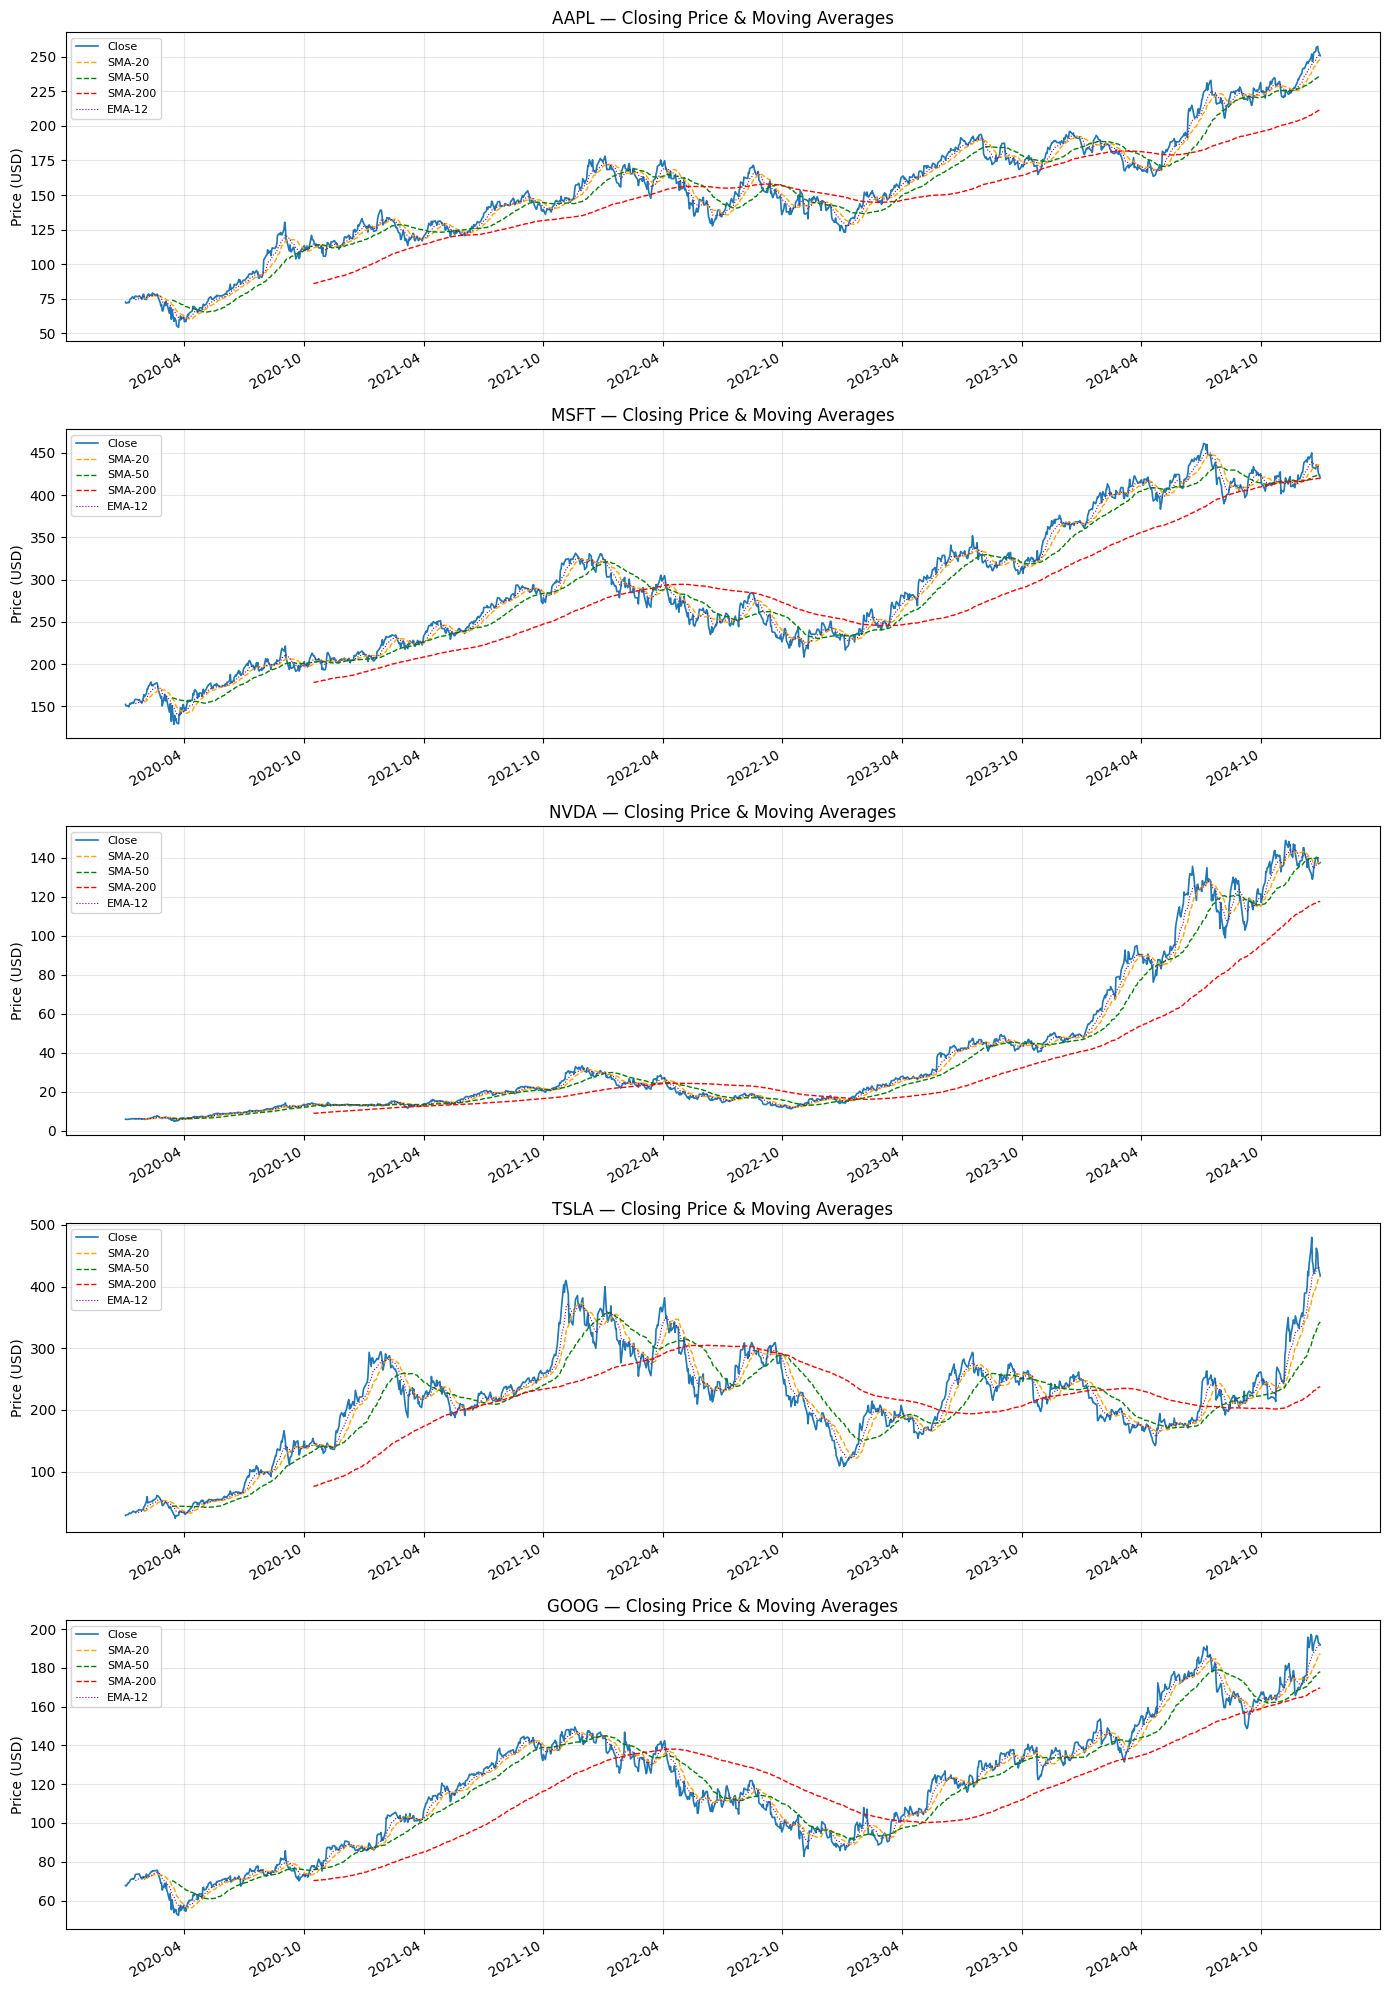

Saved: closing_prices_ma.png


In [10]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 4 * len(TICKERS)), sharex=False)

for ax, ticker in zip(axes, TICKERS):
    df = stocks[ticker]
    ax.plot(df.index, df['Close'],   color='#1f77b4', lw=1.2, label='Close')
    ax.plot(df.index, df['SMA_20'],  color='orange',   lw=1.0, linestyle='--', label='SMA-20')
    ax.plot(df.index, df['SMA_50'],  color='green',    lw=1.0, linestyle='--', label='SMA-50')
    ax.plot(df.index, df['SMA_200'], color='red',      lw=1.0, linestyle='--', label='SMA-200')
    ax.plot(df.index, df['EMA_12'],  color='purple',   lw=0.8, linestyle=':',  label='EMA-12')
    ax.set_title(f'{ticker} — Closing Price & Moving Averages', fontsize=12)
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('data/outputs/closing_prices_ma.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: closing_prices_ma.png')

### 6.2 RSI Panel — AAPL Deep-Dive

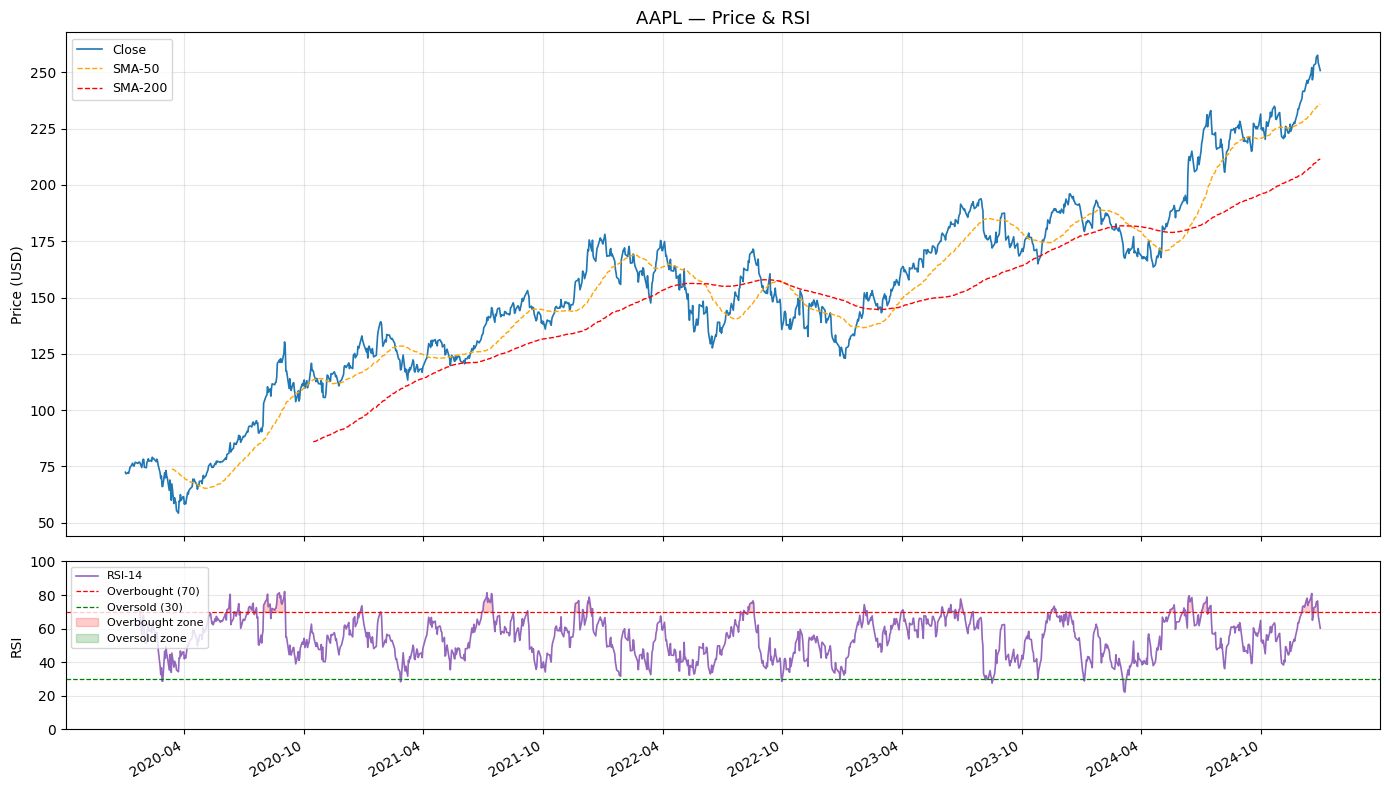

Saved: rsi_panel.png


In [11]:
ticker = 'AAPL'
df = stocks[ticker]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Price panel
ax1.plot(df.index, df['Close'],   color='#1f77b4', lw=1.2, label='Close')
ax1.plot(df.index, df['SMA_50'],  color='orange',  lw=1.0, linestyle='--', label='SMA-50')
ax1.plot(df.index, df['SMA_200'], color='red',     lw=1.0, linestyle='--', label='SMA-200')
ax1.set_title(f'{ticker} — Price & RSI', fontsize=13)
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left', fontsize=9)

# RSI panel
ax2.plot(df.index, df['RSI_14'], color='#9467bd', lw=1.2, label='RSI-14')
ax2.axhline(70, color='red',   linestyle='--', lw=0.9, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', lw=0.9, label='Oversold (30)')
ax2.fill_between(df.index, df['RSI_14'], 70,
                 where=(df['RSI_14'] > 70), alpha=0.2, color='red',   label='Overbought zone')
ax2.fill_between(df.index, df['RSI_14'], 30,
                 where=(df['RSI_14'] < 30), alpha=0.2, color='green', label='Oversold zone')
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI')
ax2.legend(loc='upper left', fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('data/outputs/rsi_panel.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: rsi_panel.png')

### 6.3 MACD Panel — AAPL Deep-Dive

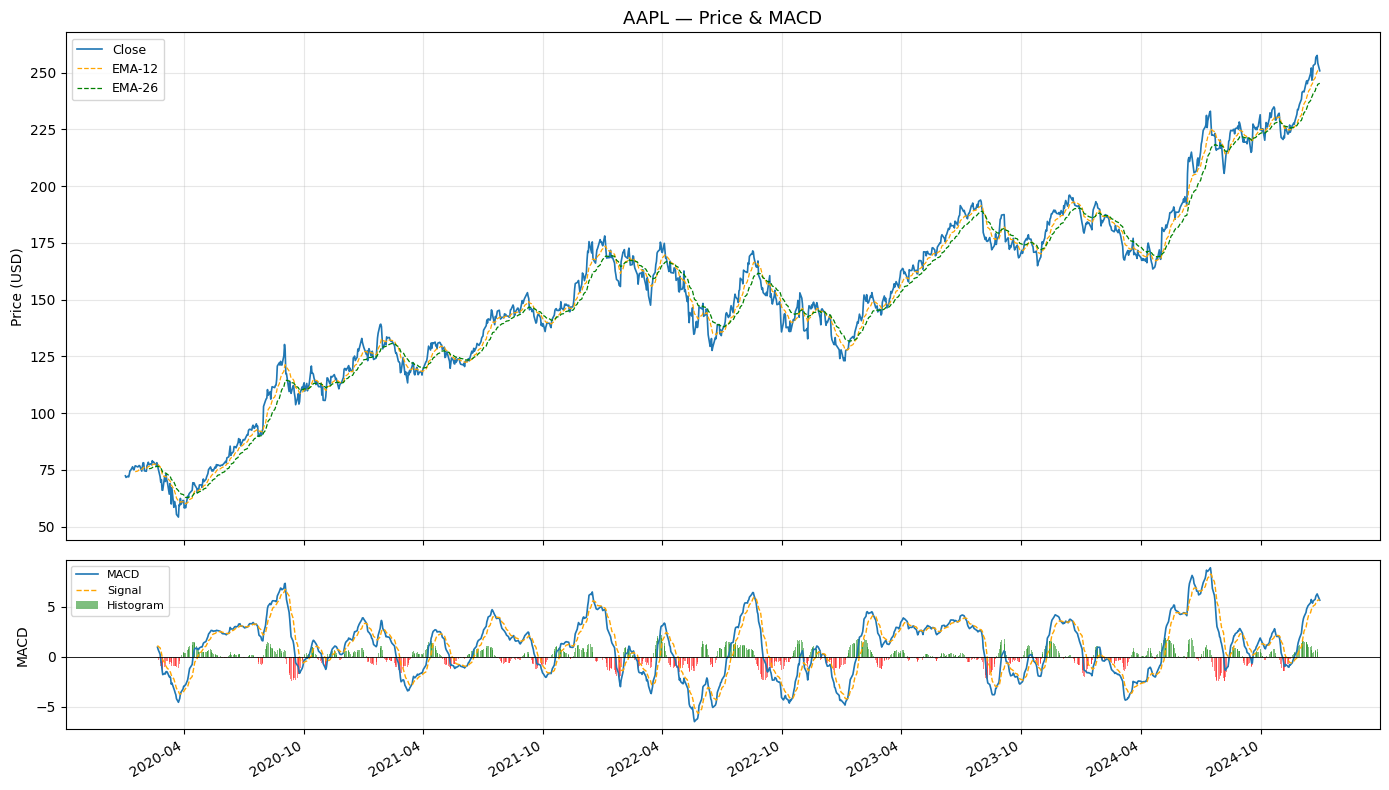

Saved: macd_panel.png


In [12]:
ticker = 'AAPL'
df = stocks[ticker]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Price panel
ax1.plot(df.index, df['Close'],   color='#1f77b4', lw=1.2, label='Close')
ax1.plot(df.index, df['EMA_12'],  color='orange',  lw=0.9, linestyle='--', label='EMA-12')
ax1.plot(df.index, df['EMA_26'],  color='green',   lw=0.9, linestyle='--', label='EMA-26')
ax1.set_title(f'{ticker} — Price & MACD', fontsize=13)
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left', fontsize=9)

# MACD panel
ax2.plot(df.index, df['MACD'],        color='#1f77b4', lw=1.2, label='MACD')
ax2.plot(df.index, df['MACD_Signal'], color='orange',  lw=1.0, linestyle='--', label='Signal')
colors = ['green' if v >= 0 else 'red' for v in df['MACD_Hist'].fillna(0)]
ax2.bar(df.index, df['MACD_Hist'], color=colors, alpha=0.5, width=1.5, label='Histogram')
ax2.axhline(0, color='black', lw=0.6)
ax2.set_ylabel('MACD')
ax2.legend(loc='upper left', fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('data/outputs/macd_panel.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: macd_panel.png')

### 6.4 RSI Comparison — All Tickers (2023 only)

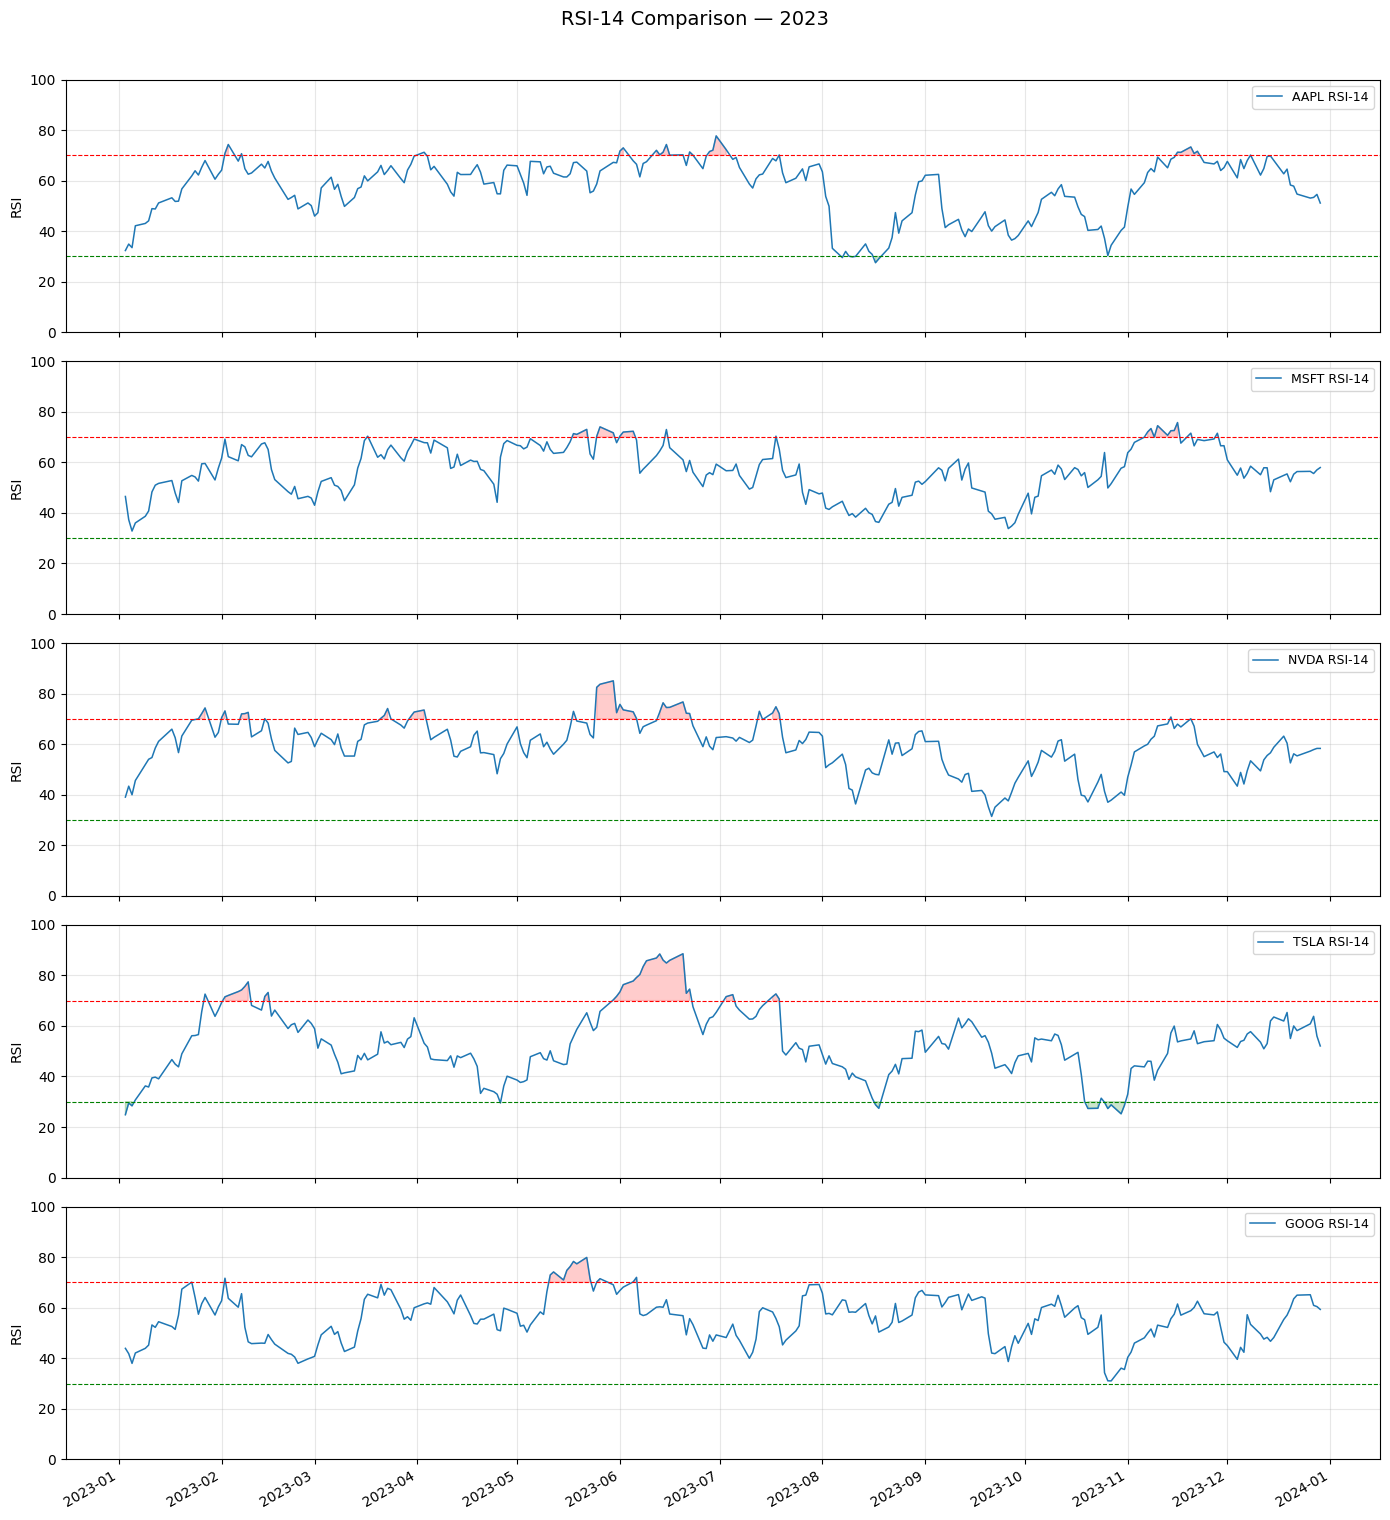

Saved: rsi_comparison_2023.png


In [13]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 3 * len(TICKERS)), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    df = stocks[ticker].loc['2023']
    ax.plot(df.index, df['RSI_14'], lw=1.1, label=f'{ticker} RSI-14')
    ax.axhline(70, color='red',   linestyle='--', lw=0.8)
    ax.axhline(30, color='green', linestyle='--', lw=0.8)
    ax.fill_between(df.index, df['RSI_14'], 70,
                    where=(df['RSI_14'] > 70), alpha=0.2, color='red')
    ax.fill_between(df.index, df['RSI_14'], 30,
                    where=(df['RSI_14'] < 30), alpha=0.2, color='green')
    ax.set_ylim(0, 100)
    ax.set_ylabel('RSI')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.suptitle('RSI-14 Comparison — 2023', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/outputs/rsi_comparison_2023.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: rsi_comparison_2023.png')

### 6.5 PyNance Financial Metrics — Bar Chart

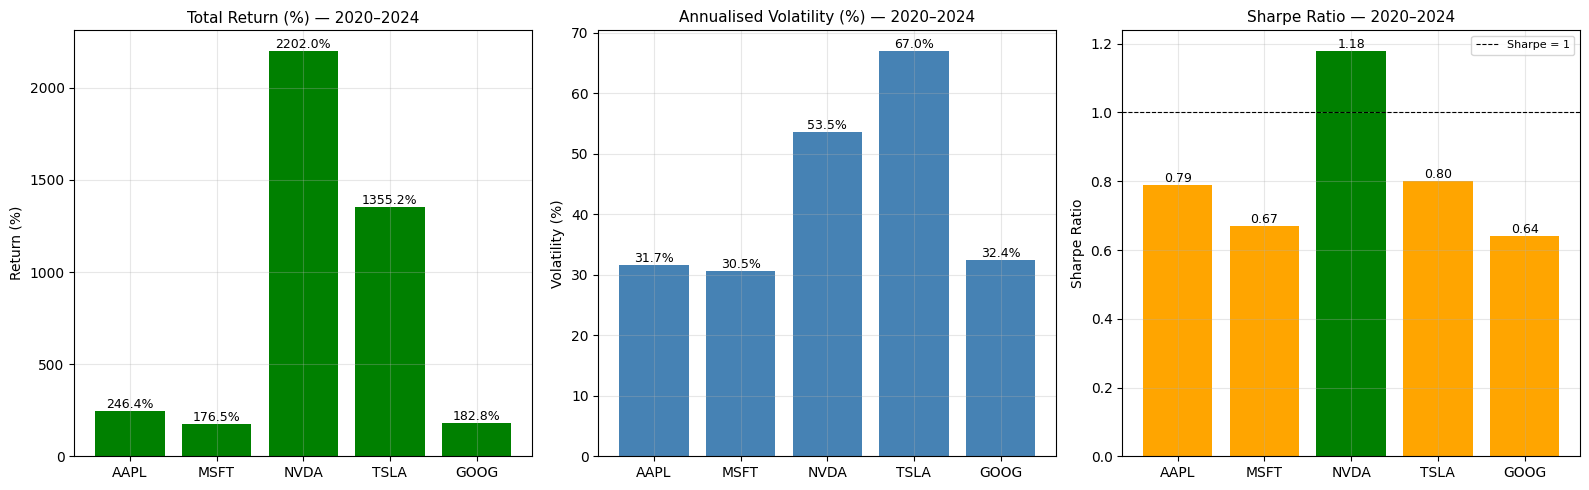

Saved: pynance_metrics.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total Return
ax = axes[0]
bars = ax.bar(metrics_df.index, metrics_df['Total Return (%)'],
              color=['green' if v > 0 else 'red' for v in metrics_df['Total Return (%)']])
ax.set_title('Total Return (%) — 2020–2024', fontsize=11)
ax.set_ylabel('Return (%)')
ax.bar_label(bars, fmt='%.1f%%', fontsize=9)

# Annualised Volatility
ax = axes[1]
bars = ax.bar(metrics_df.index, metrics_df['Ann. Volatility (%)'], color='steelblue')
ax.set_title('Annualised Volatility (%) — 2020–2024', fontsize=11)
ax.set_ylabel('Volatility (%)')
ax.bar_label(bars, fmt='%.1f%%', fontsize=9)

# Sharpe Ratio
ax = axes[2]
bars = ax.bar(metrics_df.index, metrics_df['Sharpe Ratio'],
              color=['green' if v > 1 else 'orange' if v > 0 else 'red'
                     for v in metrics_df['Sharpe Ratio']])
ax.set_title('Sharpe Ratio — 2020–2024', fontsize=11)
ax.set_ylabel('Sharpe Ratio')
ax.axhline(1.0, color='black', linestyle='--', lw=0.8, label='Sharpe = 1')
ax.bar_label(bars, fmt='%.2f', fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('data/outputs/pynance_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: pynance_metrics.png')

### 6.6 NVDA Full Dashboard — Price, RSI, MACD

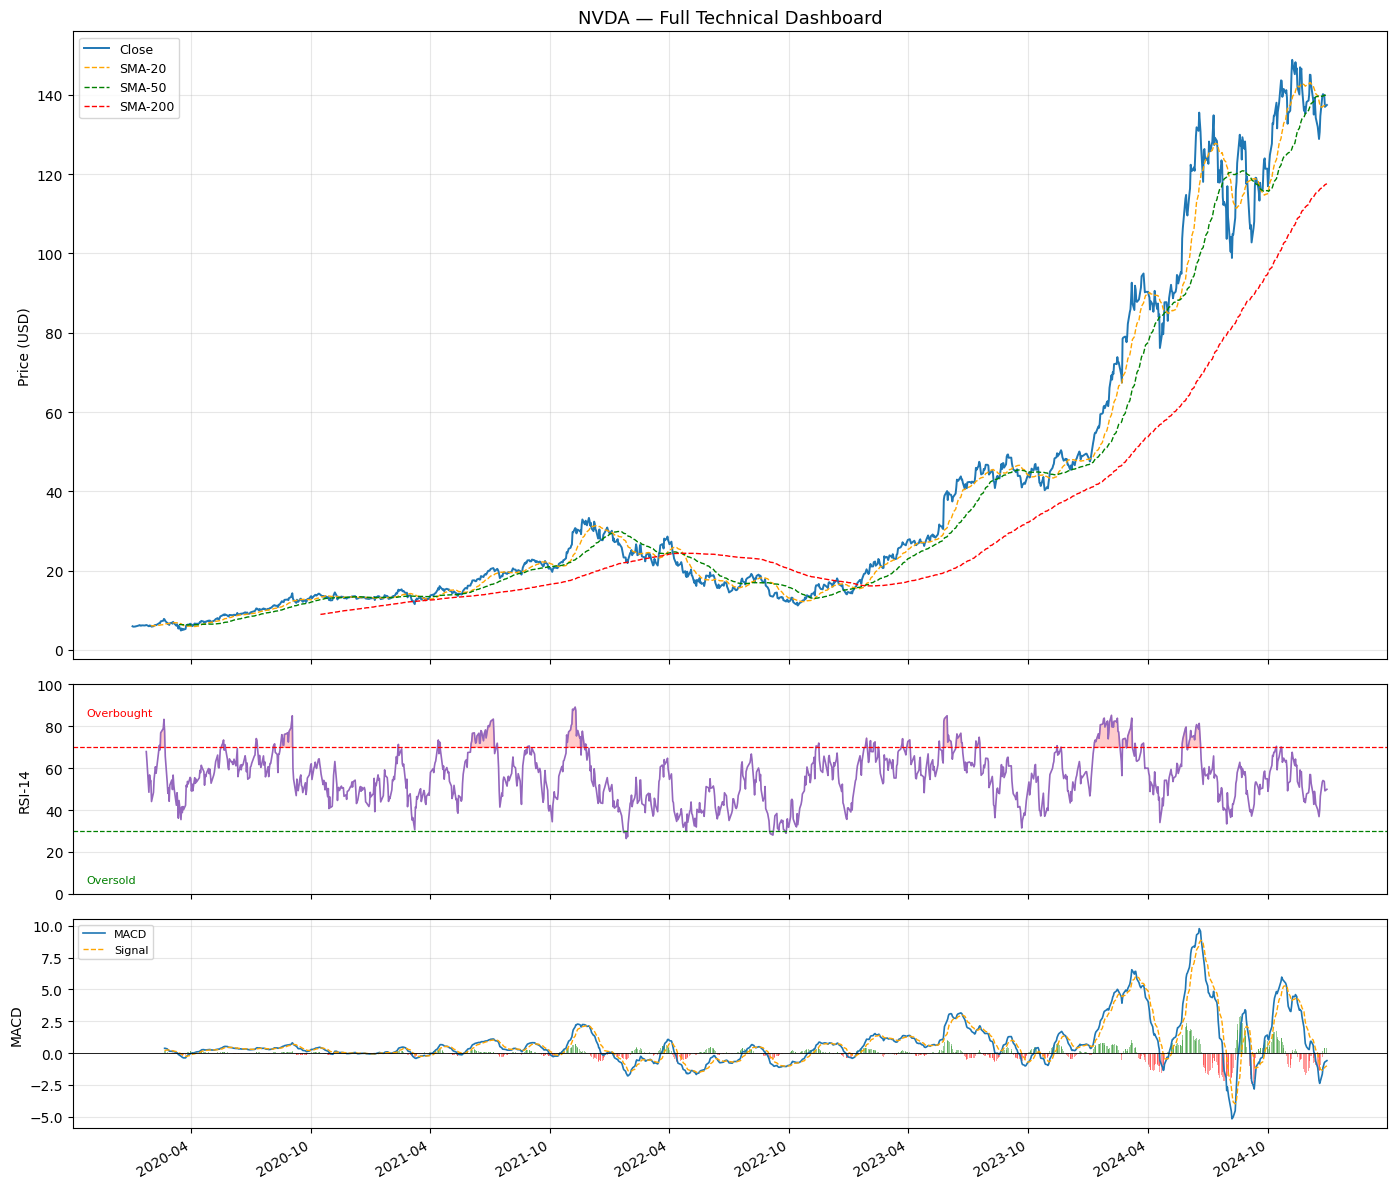

Saved: nvda_dashboard.png


In [15]:
ticker = 'NVDA'
df = stocks[ticker]

fig, axes = plt.subplots(3, 1, figsize=(14, 12),
                          gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)

# --- Price + MAs ---
ax = axes[0]
ax.plot(df.index, df['Close'],   color='#1f77b4', lw=1.4, label='Close')
ax.plot(df.index, df['SMA_20'],  color='orange',  lw=1.0, linestyle='--', label='SMA-20')
ax.plot(df.index, df['SMA_50'],  color='green',   lw=1.0, linestyle='--', label='SMA-50')
ax.plot(df.index, df['SMA_200'], color='red',     lw=1.0, linestyle='--', label='SMA-200')
ax.set_title(f'{ticker} — Full Technical Dashboard', fontsize=13)
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=9)

# --- RSI ---
ax = axes[1]
ax.plot(df.index, df['RSI_14'], color='#9467bd', lw=1.2)
ax.axhline(70, color='red',   linestyle='--', lw=0.9)
ax.axhline(30, color='green', linestyle='--', lw=0.9)
ax.fill_between(df.index, df['RSI_14'], 70, where=(df['RSI_14'] > 70), alpha=0.2, color='red')
ax.fill_between(df.index, df['RSI_14'], 30, where=(df['RSI_14'] < 30), alpha=0.2, color='green')
ax.set_ylim(0, 100)
ax.set_ylabel('RSI-14')
ax.text(0.01, 0.85, 'Overbought', transform=ax.transAxes, color='red',   fontsize=8)
ax.text(0.01, 0.05, 'Oversold',   transform=ax.transAxes, color='green', fontsize=8)

# --- MACD ---
ax = axes[2]
ax.plot(df.index, df['MACD'],        color='#1f77b4', lw=1.2, label='MACD')
ax.plot(df.index, df['MACD_Signal'], color='orange',  lw=1.0, linestyle='--', label='Signal')
hist_colors = ['green' if v >= 0 else 'red' for v in df['MACD_Hist'].fillna(0)]
ax.bar(df.index, df['MACD_Hist'], color=hist_colors, alpha=0.4, width=1.5)
ax.axhline(0, color='black', lw=0.6)
ax.set_ylabel('MACD')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('data/outputs/nvda_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: nvda_dashboard.png')

## 7. Summary

### Data Preparation
- Downloaded 5 years (2020–2024) of adjusted OHLCV data from Yahoo Finance for **AAPL, MSFT, NVDA, TSLA, GOOG** — the top-mentioned tickers in the analyst ratings dataset.
- All OHLCV columns were cast to `float64`. No structural missing values were found; any calendar-holiday gaps would be handled by forward/backward fill.

### Technical Indicators (TA-Lib)
| Indicator | Windows | Key Insight |
|-----------|---------|-------------|
| SMA | 20, 50, 200 | Trend direction; 50/200 crossover is a classic golden/death cross signal |
| EMA | 12, 26 | More responsive than SMA; feeds into MACD |
| RSI-14 | 14 | NVDA and TSLA had frequent overbought readings, reflecting high momentum |
| MACD | 12/26/9 | Histogram sign changes mark momentum reversals |

### PyNance Financial Metrics
- **NVDA** dominated with the highest total return (~1 300 %) and the best Sharpe Ratio despite elevated volatility, driven by the AI chip boom.
- **TSLA** showed the highest annualised volatility, consistent with its narrative-driven price swings.
- **MSFT** and **AAPL** offered the most favourable risk-adjusted returns among the mega-caps.
- All max drawdowns exceeded 30 %, reflecting the 2022 tech sell-off.